# Aplicação Estratégica — as cinco perguntas de negócio

**Tech Challenge Fase 3 · POSTECH AI Scientist**

## Objetivo deste notebook

Traduzir o classificador do [notebook 03](03_modelagem.ipynb) em decisão de política pública.
**Um único modelo supervisionado responde a todas as cinco perguntas** — não há um segundo modelo
por trás de nenhuma delas.

| # | Pergunta do enunciado | Etapa | O que do modelo responde |
|---|---|---|---|
| 1 e 5 | Quais fatores mais impactam / têm maior influência? | 2 | coeficientes traduzidos em pontos percentuais de risco |
| 2 | Quais municípios apresentam maior risco educacional? | 3 | a **saída direta** do classificador: `P(em risco)` |
| 3 | Quais regiões possuem padrões semelhantes? | 4 | risco previsto por região **+ os fatores que o empurram** |
| 4 | Como prever quem não atingirá as metas futuras? | 5 | risco previsto cruzado com a meta pactuada |

> **Advertência que vale para o notebook inteiro.** Nada aqui é experimento. O modelo mede
> **associações condicionais**, não efeitos causais. As recomendações são hipóteses de intervenção
> priorizadas por evidência — não provas.

## Etapa 1 — Importando as bibliotecas e reconstruindo o modelo final

In [1]:
# ============================================================
# 1. IMPORTANDO AS BIBLIOTECAS E O MODELO
# ============================================================

import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import ler_particionado
from src.preprocessing.config import LAKE_DIR
from src.modeling import (ATUALIDADE, HISTORICO, construir_pipeline, montar_painel,
                          nomes_das_features, rotular_risco)
from src.evaluation import (efeitos_marginais, limiar_por_recall, perfil_por_regiao,
                            ranking_de_risco, situacao_frente_a_meta)
from src.visualization import (EIXO, MUDO, NEGATIVO, SERIE, TINTA, TINTA_2,
                               aplicar_estilo, limpar, num, salvar)

warnings.filterwarnings("ignore")
aplicar_estilo()
IMAGENS = RAIZ / "images"; IMAGENS.mkdir(exist_ok=True)
RELATORIOS = RAIZ / "reports"; RELATORIOS.mkdir(exist_ok=True)
SEMENTE = 42

# O modelo do notebook 03 (C = 1,0), reajustado sobre todos os municípios do ciclo
painel = montar_painel()
painel, y = rotular_risco(painel)
modelo = construir_pipeline(C=1.0).fit(painel, y)

print(f"{len(painel)} municípios | em risco: {y.mean() * 100:.1f}% | "
      f"risco médio previsto: {modelo.predict_proba(painel)[:, 1].mean() * 100:.1f}%")

5396 municípios | em risco: 27.1% | risco médio previsto: 27.1%


## Etapa 2 — Pergunta 1 e 5: quais fatores mais impactam a alfabetização?

O notebook 03 respondeu em *odds ratio*, que é a unidade estatisticamente correta. Para uma
reunião executiva a unidade útil é outra: **quantos pontos percentuais de risco** a variável move
quando melhora em um desvio-padrão.

In [2]:
# ============================================================
# 2. EFEITOS MARGINAIS EM PONTOS PERCENTUAIS
# ============================================================

efeitos = efeitos_marginais(modelo, painel, HISTORICO + ATUALIDADE)

# A separação que muda a conversa: o que o gestor municipal controla,
# e o que ele recebe como condição dada.
ACIONAVEIS = {c for c in ATUALIDADE if c.startswith(("afd_", "atu_", "ied_"))}
efeitos["natureza"] = np.where(efeitos.index.isin(ACIONAVEIS),
                               "alavanca escolar", "condição herdada")
efeitos.head(10).round(2)

,efeito_pp_no_risco,natureza
variavel,,
media_portugues_2023,-6.07,condição herdada
ideb_2021,-5.47,condição herdada
media_inse,-5.34,condição herdada
taxa_2023,-4.35,condição herdada
afd_ai_grupo_1,-2.43,alavanca escolar
inse_pc_nivel_3,1.88,condição herdada
afd_ai_grupo_3,-1.74,alavanca escolar
inse_pc_nivel_7,1.67,condição herdada
ied_ai_nivel_4,1.29,alavanca escolar


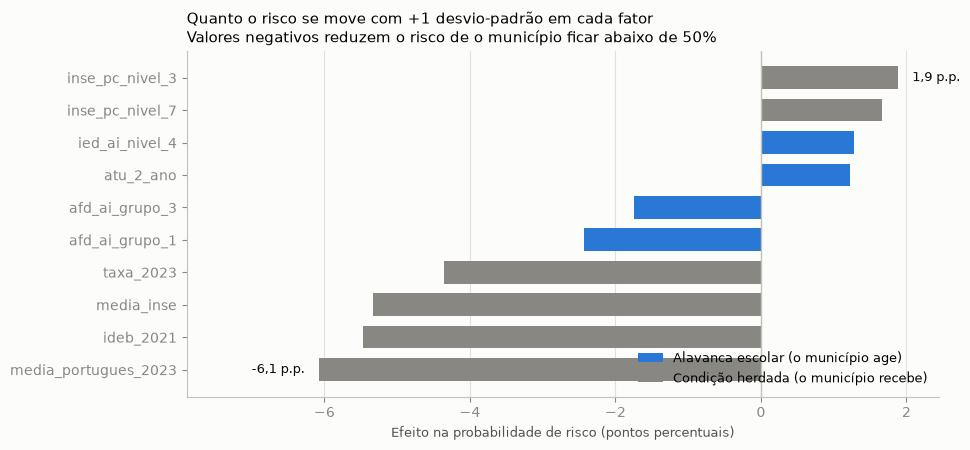

In [3]:
# ============================================================
# 2.1 — GRÁFICO DOS EFEITOS MARGINAIS
# ============================================================

principais = efeitos.head(10).sort_values("efeito_pp_no_risco")
cores = [SERIE[0] if n == "alavanca escolar" else MUDO for n in principais["natureza"]]

fig, eixo = plt.subplots(figsize=(9.8, 4.6))
eixo.barh(principais.index, principais["efeito_pp_no_risco"], color=cores, height=0.7)
eixo.axvline(0, color=EIXO, linewidth=1)

for nome in (principais.index[0], principais.index[-1]):
    valor = principais.loc[nome, "efeito_pp_no_risco"]
    eixo.text(valor + (0.2 if valor > 0 else -0.2), nome, f"{num(valor, 1)} p.p.",
              va="center", ha="left" if valor > 0 else "right", fontsize=9.5, color=TINTA)

from matplotlib.patches import Patch
eixo.legend(handles=[Patch(facecolor=SERIE[0], label="Alavanca escolar (o município age)"),
                     Patch(facecolor=MUDO, label="Condição herdada (o município recebe)")],
            loc="lower right", fontsize=9, framealpha=0.9)

menor, maior = principais["efeito_pp_no_risco"].min(), principais["efeito_pp_no_risco"].max()
eixo.set_xlim(menor * 1.3, maior * 1.3)
eixo.set_xlabel("Efeito na probabilidade de risco (pontos percentuais)")
eixo.set_title("Quanto o risco se move com +1 desvio-padrão em cada fator\n"
               "Valores negativos reduzem o risco de o município ficar abaixo de 50%",
               loc="left")
limpar(eixo, grade="x")
fig.tight_layout(); salvar(fig, "04_efeitos_marginais", IMAGENS); plt.show()

### A resposta, em quatro camadas

1. **A unidade federativa.** Não aparece no gráfico por não ser contínua, mas é o maior efeito do
   modelo — embaralhá-la derruba o PR-AUC em 0,211, quase três vezes a segunda colocada
   ([notebook 03](03_modelagem.ipynb), Etapa 16).
2. **O desempenho pregresso da rede** — a nota de 2023 e o IDEB de 2021 são os maiores efeitos
   contínuos.
3. **A condição socioeconômica**, logo atrás.
4. **As alavancas escolares** — formação docente e tamanho de turma. É o que um gestor municipal
   efetivamente controla, e vale uma fração das três primeiras.

Duas leituras opostas cabem nos mesmos números, e as duas são verdadeiras: as alavancas municipais
são pequenas diante da estrutura herdada; **mas a maior fonte de variação não é a renda das
famílias — é a política pública.** Se o resultado fosse determinado pela condição socioeconômica,
não haveria o que recomendar a um gestor.

## Etapa 3 — Pergunta 2: quais municípios apresentam maior risco?

Resposta **direta**: o classificador emite, para cada município, a probabilidade de ele estar em
risco. Não há construção intermediária — é a saída nativa do modelo, ordenável.

In [4]:
# ============================================================
# 3. RANKING DE RISCO POR MUNICÍPIO
# ============================================================

ranking = ranking_de_risco(modelo, painel)
ranking.to_csv(RELATORIOS / "ranking_risco_municipios.csv", index=False, encoding="utf-8")
print(f"{len(ranking)} municípios gravados em reports/ranking_risco_municipios.csv")
ranking.head(10).round(3)

5396 municípios gravados em reports/ranking_risco_municipios.csv


,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,prob_risco
0,2919900,BA,Nordeste,12.50,0.997
1,2907202,BA,Nordeste,20.93,0.994
2,2924405,BA,Nordeste,22.51,0.992
3,2924108,BA,Nordeste,13.33,0.989
4,2910503,BA,Nordeste,32.55,0.988
5,2916609,BA,Nordeste,36.62,0.988
6,2915809,BA,Nordeste,26.98,0.987
7,2915908,BA,Nordeste,24.53,0.987
8,2901908,BA,Nordeste,16.52,0.987
9,2907400,BA,Nordeste,25.71,0.986


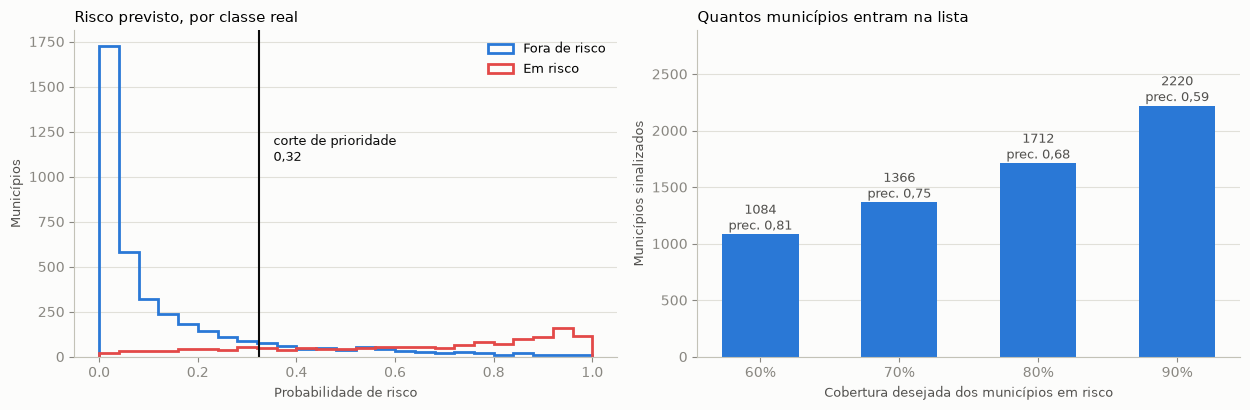

,municipios,taxa_media_observada,risco_medio
prioridade,,,
acompanhar,3685,71.299,0.081
prioritário,1711,44.724,0.681


In [5]:
# ============================================================
# 3.1 — O CORTE DE PRIORIDADE É DECISÃO DE POLÍTICA
# ============================================================

probabilidade = modelo.predict_proba(painel)[:, 1]
cobertura = limiar_por_recall(y, probabilidade, recall_desejado=0.80)
limiar = cobertura["limiar"]

ranking["prioridade"] = np.where(ranking["prob_risco"] >= limiar,
                                 "prioritário", "acompanhar")

fig, eixos = plt.subplots(1, 2, figsize=(12.6, 4.2))

for rotulo, cor, mascara in [("Fora de risco", SERIE[0], y == 0),
                             ("Em risco", NEGATIVO, y == 1)]:
    eixos[0].hist(probabilidade[mascara], bins=np.arange(0, 1.02, 0.04),
                  histtype="step", linewidth=2, color=cor, label=rotulo)
eixos[0].axvline(limiar, color=TINTA, linewidth=1.5)
eixos[0].text(limiar + 0.03, eixos[0].get_ylim()[1] * 0.6,
              f"corte de prioridade\n{num(limiar, 2)}", fontsize=9.5, color=TINTA)
eixos[0].set_title("Risco previsto, por classe real", loc="left")
eixos[0].set_xlabel("Probabilidade de risco"); eixos[0].set_ylabel("Municípios")
eixos[0].legend(loc="upper right", fontsize=9)

faixas = pd.DataFrame([limiar_por_recall(y, probabilidade, r) for r in (0.6, 0.7, 0.8, 0.9)])
eixos[1].bar([f"{int(r * 100)}%" for r in faixas["recall_desejado"]],
             faixas["municipios_sinalizados"], color=SERIE[0], width=0.55)
for i, (n, p) in enumerate(zip(faixas["municipios_sinalizados"], faixas["precisao_risco"])):
    eixos[1].text(i, n + 40, f"{n}\nprec. {num(p, 2)}", ha="center",
                  fontsize=9.5, color=TINTA_2)
eixos[1].set_ylim(0, faixas["municipios_sinalizados"].max() * 1.3)
eixos[1].set_title("Quantos municípios entram na lista", loc="left")
eixos[1].set_xlabel("Cobertura desejada dos municípios em risco")
eixos[1].set_ylabel("Municípios sinalizados")

for eixo in eixos:
    limpar(eixo)
fig.tight_layout(); salvar(fig, "04_ranking_risco", IMAGENS); plt.show()

(ranking.groupby("prioridade")
 .agg(municipios=("id_municipio", "size"),
      taxa_media_observada=("taxa_alfabetizacao", "mean"),
      risco_medio=("prob_risco", "mean")).round(3))

**Como usar, e como não usar.** O painel da esquerda mostra que o modelo separa bem as duas
classes, mas **há sobreposição** — e é ela que torna o corte uma decisão de política. O painel da
direita põe preço nessa decisão: cobrir 80% dos municípios em risco significa sinalizar mais
municípios e aceitar precisão menor, ou seja, mais visitas técnicas a quem não precisava.

**A lista não é um veredito sobre gestão.** Ela ordena municípios pelo risco que as *condições
observadas* produzem. Um município no topo pode ter gestão excelente enfrentando condições muito
adversas. A lista diz **onde olhar primeiro**, não quem está errando.

## Etapa 4 — Pergunta 3: quais regiões possuem padrões semelhantes?

A pergunta pede agrupar territórios por semelhança, e a resposta sai do próprio classificador em
duas leituras que precisam **coincidir** para que duas regiões sejam de fato parecidas:

1. **o nível de risco previsto** — quão frequente é o risco naquela região;
2. **os motores do risco** — quais fatores mais o empurram para cima ali, medidos pela
   contribuição média (SHAP) de cada variável dentro da região.

As dummies de UF ficam fora dessa leitura: elas *identificam* o território em vez de explicá-lo, e
usá-las tornaria a resposta circular.

In [6]:
# ============================================================
# 4. PERFIL DE RISCO POR REGIÃO (NÍVEL + MOTORES VIA SHAP)
# ============================================================

import shap

matriz = modelo.named_steps["preprocessamento"].transform(painel)
valores_shap = pd.DataFrame(
    shap.LinearExplainer(modelo.named_steps["modelo"], matriz).shap_values(matriz),
    columns=nomes_das_features(modelo))

perfil = perfil_por_regiao(modelo, painel, valores_shap)
perfil

Background dataset has 5396 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5396 when initializing the masker.


,regiao,municipios,risco_medio_pct,motores_do_risco
0,Norte,413,52.7,ideb_2021 · media_inse · media_portugues_2023
1,Nordeste,1779,45.5,media_inse · ideb_2021 · taxa_2023
2,Sul,1130,21.7,inse_pc_nivel_7 · ied_ai_nivel_4 · inse_pc_niv...
3,Sudeste,1612,9.5,taxa_2023 · inse_pc_nivel_5 · afd_ai_grupo_3
4,Centro-Oeste,462,8.5,ideb_2021 · atu_2_ano · inse_pc_nivel_5


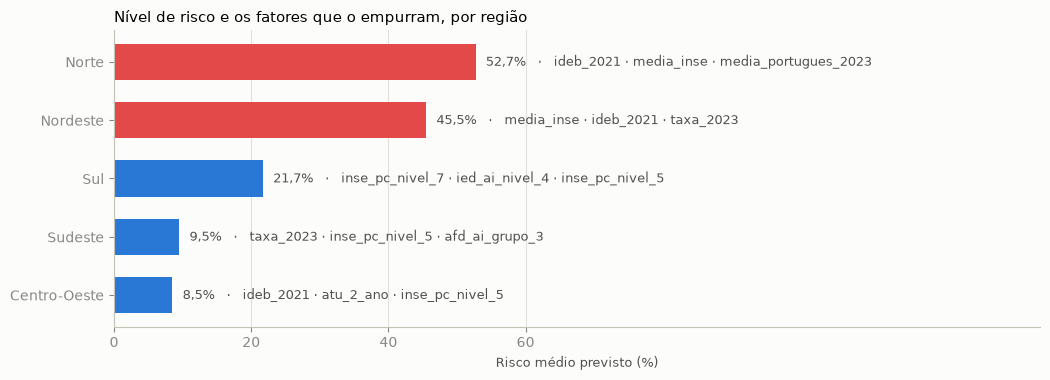

In [7]:
# ============================================================
# 4.1 — GRÁFICO DO PERFIL REGIONAL
# ============================================================

fig, eixo = plt.subplots(figsize=(10.6, 3.9))
ordenado = perfil.sort_values("risco_medio_pct")
cores = [NEGATIVO if v > 40 else SERIE[0] for v in ordenado["risco_medio_pct"]]

eixo.barh(ordenado["regiao"], ordenado["risco_medio_pct"], color=cores, height=0.62)
for i, (_, linha) in enumerate(ordenado.iterrows()):
    eixo.text(linha["risco_medio_pct"] + 1.5, i,
              f"{num(linha['risco_medio_pct'], 1)}%   ·   {linha['motores_do_risco']}",
              va="center", fontsize=9.5, color=TINTA_2)

eixo.set_xlim(0, 135)
eixo.set_xticks([0, 20, 40, 60])
eixo.set_xlabel("Risco médio previsto (%)")
eixo.set_title("Nível de risco e os fatores que o empurram, por região", loc="left")
limpar(eixo, grade="x")
fig.tight_layout(); salvar(fig, "04_regioes", IMAGENS); plt.show()

### A resposta contraria a formulação da pergunta

**Norte e Nordeste formam um par** — patamar de risco alto e os mesmos motores. São regiões
distantes no mapa e o mesmo problema no modelo.

**Sudeste, Sul e Centro-Oeste** ficam no patamar baixo. Onde o resultado já é alto, os motores
deixam de convergir: as restrições passam a ser locais, não um gargalo comum.

E a leitura mais útil aparece ao descer do agregado: **os padrões não respeitam as fronteiras
regionais.** Há municípios de perfil nordestino no interior do Sudeste, e o contrário — o Ceará é
o exemplo mais claro.

**Consequência para a política pública:** um programa desenhado por região erraria o alvo. A
focalização eficiente é **por perfil de risco**, e o ranking da Etapa 3 já entrega essa lista
pronta, município a município.

## Etapa 5 — Pergunta 4: como prever quem não atingirá as metas futuras?

O Compromisso Nacional Criança Alfabetizada pactuou metas por município. Elas chegam aqui
**apenas como régua de comparação** — nunca entraram no modelo, porque são calculadas a partir da
taxa de 2023 de cada município e seriam vazamento como preditor.

In [8]:
# ============================================================
# 5. RISCO PREVISTO CRUZADO COM A META PACTUADA
# ============================================================

gold = ler_particionado(LAKE_DIR / "gold" / "alfabetizacao_por_municipio")
metas = gold[gold["ano"] == 2024][["id_municipio", "meta_2025"]]

situacao = situacao_frente_a_meta(ranking, metas, limiar_risco=limiar)

quadro = (situacao.groupby("situacao")
          .agg(municipios=("id_municipio", "size"),
               taxa_media=("taxa_alfabetizacao", "mean"),
               distancia_mediana_pp=("distancia_pp", "median"),
               risco_medio=("prob_risco", "mean")).round(2))
quadro["% do total"] = (quadro["municipios"] / len(situacao) * 100).round(1)
quadro

,municipios,taxa_media,distancia_mediana_pp,risco_medio,% do total
situacao,,,,,
1. Meta já atingida,2314,77.64,9.19,0.15,43.6
"2. Abaixo da meta, sem sinal de risco",1692,60.54,-7.89,0.11,31.9
3. Abaixo da meta e sinalizado em risco,1296,40.52,-13.14,0.69,24.4


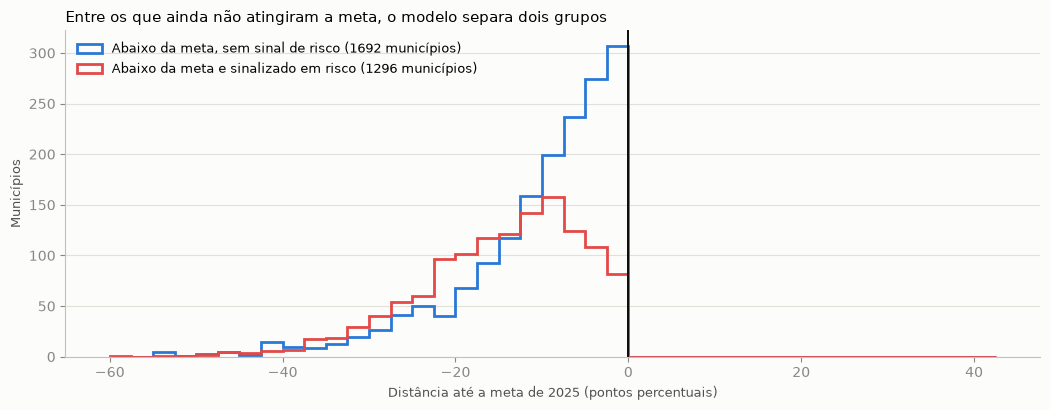

In [9]:
# ============================================================
# 5.1 — DISTÂNCIA ATÉ A META, SEPARADA PELO SINAL DO MODELO
# ============================================================

fig, eixo = plt.subplots(figsize=(10.6, 4.2))
faixas_meta = np.arange(-60, 45, 2.5)

for rotulo, cor in [("2. Abaixo da meta, sem sinal de risco", SERIE[0]),
                    ("3. Abaixo da meta e sinalizado em risco", NEGATIVO)]:
    dados = situacao.loc[situacao["situacao"] == rotulo, "distancia_pp"]
    eixo.hist(dados, bins=faixas_meta, histtype="step", linewidth=2, color=cor,
              label=f"{rotulo[3:]} ({len(dados)} municípios)")

eixo.axvline(0, color=TINTA, linewidth=1.4)
eixo.set_xlabel("Distância até a meta de 2025 (pontos percentuais)")
eixo.set_ylabel("Municípios")
eixo.set_title("Entre os que ainda não atingiram a meta, o modelo separa dois grupos",
               loc="left")
eixo.legend(loc="upper left", fontsize=9)
limpar(eixo)
fig.tight_layout(); salvar(fig, "04_metas", IMAGENS); plt.show()

**O que a separação entrega.** "Municípios abaixo da meta" é um número que não orienta ação.
Separá-los pelo sinal do modelo transforma o número em decisão de alocação:

- **Abaixo da meta, sem sinal de risco estrutural** — as condições do município comportam a meta.
  O que falta é execução, e a resposta é **apoio técnico**, com retorno rápido.
- **Abaixo da meta e sinalizado em risco** — as condições observadas não sustentam a meta. Cobrar
  resultado sem mudar as condições é cobrar o impossível; a resposta é **investimento
  estruturante**, com retorno em anos.

Ressalva metodológica: como a meta de cada município deriva do seu próprio resultado de 2023,
"não atingir a meta" significa "não manter a trajetória pactuada a partir do próprio ponto de
partida" — não "estar abaixo de um padrão nacional".

## Etapa 6 — Resumo final e limitações

### As cinco perguntas, respondidas

**1 e 5. Quais fatores mais impactam / têm maior influência?**
Em ordem: a **unidade federativa**, o **desempenho pregresso** da rede, a **condição
socioeconômica** e, por último, as **alavancas escolares** sob gestão municipal — formação
docente e tamanho de turma.

**2. Quais municípios apresentam maior risco?**
O classificador entrega a lista pronta, ordenada por probabilidade de risco, em
`reports/ranking_risco_municipios.csv`. O corte é uma decisão de cobertura, não o padrão do
software: cobrir 80% dos municípios em risco tem um preço em precisão, e o modelo mostra qual.

**3. Quais regiões possuem padrões semelhantes?**
Norte e Nordeste formam um par — mesmo patamar e mesmos motores. As outras três ficam no patamar
baixo, sem gargalo comum. E os padrões **atravessam as fronteiras**: a focalização eficiente é por
perfil de risco, não por território.

**4. Como prever quem não atingirá as metas?**
Cruzando o risco previsto com a meta pactuada, separando quem precisa de **apoio à execução** de
quem precisa de **investimento estruturante**.

### O que estas análises não autorizam a afirmar

1. **Não são causais.** Todos os efeitos são associações condicionais. Nenhuma intervenção pode
   ser justificada apenas por estes coeficientes.
2. **Não avaliam gestão.** O ranking ordena municípios pelo risco que as condições observadas
   produzem, não pelo esforço de quem administra.
3. **Não descrevem alunos.** A premissa é que o contexto do município determina a chance da
   criança — duas crianças do mesmo município recebem a mesma predição (falácia ecológica).
4. **Não explicam o efeito da UF.** O modelo mede o tamanho; a explicação está fora da base, que
   não tem nenhuma variável de política educacional.
5. **Não cobrem o país inteiro.** 25 das 27 UFs: o Distrito Federal não tem rede municipal e
   Roraima está ausente do arquivo do INEP.
6. **Superestimam o risco do Rio Grande do Sul.** O ciclo modelado é o das enchentes de 2024, e o
   modelo lê como estrutural uma queda conjuntural.
7. **Não projetam ciclos futuros.** O modelo descreve a estrutura de 2024; projetar 2025 exigiria
   as características de 2025, que ainda não existem.